# Task 04 - Image to Image Translation (pix2pix cGAN)
Prodigy InfoTech internship

pix2pix on the facades dataset - label maps to real building photos. Use GPU runtime.

In [23]:
import tensorflow as tf
import os, time, pathlib
import matplotlib.pyplot as plt
from IPython import display

print(tf.__version__, tf.config.list_physical_devices('GPU'))

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
_URL = 'http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz'

data_dir = pathlib.Path('/content/datasets')
data_dir.mkdir(parents=True, exist_ok=True)
tar_path = data_dir / 'facades.tar.gz'

if not tar_path.exists():
    import urllib.request
    urllib.request.urlretrieve(_URL, tar_path)

import tarfile
with tarfile.open(tar_path) as tar:
    tar.extractall(data_dir)

PATH = data_dir / 'facades'
list(PATH.iterdir())

/tmp/ipykernel_4449/2669362854.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


[PosixPath('/content/datasets/facades/val'),
 PosixPath('/content/datasets/facades/train'),
 PosixPath('/content/datasets/facades/test')]

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

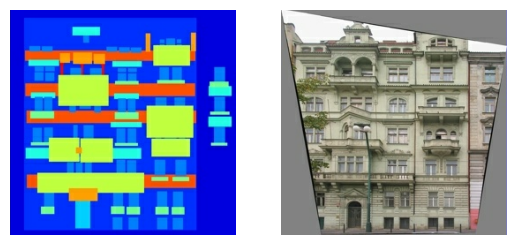

In [25]:
# each file is real|label stuck side by side, split it
def load(image_file):
    image = tf.io.decode_jpeg(tf.io.read_file(image_file))
    w = tf.shape(image)[1] // 2
    real_image = tf.cast(image[:, :w, :], tf.float32)
    input_image = tf.cast(image[:, w:, :], tf.float32)
    return input_image, real_image

inp, re = load(str(PATH / 'train/100.jpg'))
plt.subplot(1,2,1); plt.imshow(inp/255.0); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(re/255.0); plt.axis('off')

In [26]:
BUFFER_SIZE, BATCH_SIZE, IMG_H, IMG_W = 400, 1, 256, 256

def resize(inp, re, h, w):
    inp = tf.image.resize(inp, [h, w], method='nearest')
    re = tf.image.resize(re, [h, w], method='nearest')
    return inp, re

def random_crop(inp, re):
    stacked = tf.stack([inp, re], axis=0)
    cropped = tf.image.random_crop(stacked, size=[2, IMG_H, IMG_W, 3])
    return cropped[0], cropped[1]

def normalize(inp, re):
    return (inp/127.5)-1, (re/127.5)-1

@tf.function
def random_jitter(inp, re):
    inp, re = resize(inp, re, 286, 286)
    inp, re = random_crop(inp, re)
    if tf.random.uniform(()) > 0.5:
        inp, re = tf.image.flip_left_right(inp), tf.image.flip_left_right(re)
    return inp, re

def load_train(f):
    inp, re = load(f)
    inp, re = random_jitter(inp, re)
    return normalize(inp, re)

def load_test(f):
    inp, re = load(f)
    inp, re = resize(inp, re, IMG_H, IMG_W)
    return normalize(inp, re)

In [27]:
train_dataset = tf.data.Dataset.list_files(str(PATH/'train/*.jpg'))
train_dataset = train_dataset.map(load_train, num_parallel_calls=tf.data.AUTOTUNE).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

try:
    test_dataset = tf.data.Dataset.list_files(str(PATH/'test/*.jpg'))
except tf.errors.InvalidArgumentError:
    test_dataset = tf.data.Dataset.list_files(str(PATH/'val/*.jpg'))
test_dataset = test_dataset.map(load_test).batch(BATCH_SIZE)

### Generator (U-Net) + Discriminator (PatchGAN)

In [28]:
def downsample(f, s, bn=True):
    init = tf.random_normal_initializer(0., 0.02)
    r = tf.keras.Sequential()
    r.add(tf.keras.layers.Conv2D(f, s, strides=2, padding='same', kernel_initializer=init, use_bias=False))
    if bn: r.add(tf.keras.layers.BatchNormalization())
    r.add(tf.keras.layers.LeakyReLU())
    return r

def upsample(f, s, dropout=False):
    init = tf.random_normal_initializer(0., 0.02)
    r = tf.keras.Sequential()
    r.add(tf.keras.layers.Conv2DTranspose(f, s, strides=2, padding='same', kernel_initializer=init, use_bias=False))
    r.add(tf.keras.layers.BatchNormalization())
    if dropout: r.add(tf.keras.layers.Dropout(0.5))
    r.add(tf.keras.layers.ReLU())
    return r

In [29]:
def Generator():
    inputs = tf.keras.layers.Input(shape=[256,256,3])
    down_stack = [downsample(64,4,False), downsample(128,4), downsample(256,4), downsample(512,4),
                  downsample(512,4), downsample(512,4), downsample(512,4), downsample(512,4)]
    up_stack = [upsample(512,4,True), upsample(512,4,True), upsample(512,4,True),
                upsample(512,4), upsample(256,4), upsample(128,4), upsample(64,4)]
    init = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(3, 4, strides=2, padding='same', kernel_initializer=init, activation='tanh')

    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])
    return tf.keras.Model(inputs=inputs, outputs=last(x))

generator = Generator()

In [30]:
def Discriminator():
    init = tf.random_normal_initializer(0., 0.02)
    inp = tf.keras.layers.Input(shape=[256,256,3], name='input_image')
    tar = tf.keras.layers.Input(shape=[256,256,3], name='target_image')
    x = tf.keras.layers.concatenate([inp, tar])
    x = downsample(64,4,False)(x)
    x = downsample(128,4)(x)
    x = downsample(256,4)(x)
    x = tf.keras.layers.ZeroPadding2D()(x)
    x = tf.keras.layers.Conv2D(512,4,strides=1,kernel_initializer=init,use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)
    x = tf.keras.layers.ZeroPadding2D()(x)
    x = tf.keras.layers.Conv2D(1,4,strides=1,kernel_initializer=init)(x)
    return tf.keras.Model(inputs=[inp, tar], outputs=x)

discriminator = Discriminator()

### Losses - gan loss + L1 (lambda=100) for the generator, plain bce for the discriminator

In [31]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA = 100

def generator_loss(disc_gen_out, gen_out, target):
    gan_loss = loss_object(tf.ones_like(disc_gen_out), disc_gen_out)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_out))
    return gan_loss + LAMBDA*l1_loss, gan_loss, l1_loss

def discriminator_loss(disc_real_out, disc_gen_out):
    real_loss = loss_object(tf.ones_like(disc_real_out), disc_real_out)
    gen_loss = loss_object(tf.zeros_like(disc_gen_out), disc_gen_out)
    return real_loss + gen_loss

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

checkpoint_dir = './training_checkpoints'
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer, discriminator_optimizer=discriminator_optimizer,
                                  generator=generator, discriminator=discriminator)

In [32]:
def generate_images(model, test_input, tar):
    pred = model(test_input, training=True)
    plt.figure(figsize=(15,15))
    for i, (img, title) in enumerate(zip([test_input[0], tar[0], pred[0]], ['input','ground truth','predicted'])):
        plt.subplot(1,3,i+1); plt.title(title); plt.imshow(img*0.5+0.5); plt.axis('off')
    plt.show()

@tf.function
def train_step(input_image, target, step):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)
        disc_real = discriminator([input_image, target], training=True)
        disc_gen = discriminator([input_image, gen_output], training=True)
        gen_loss, _, _ = generator_loss(disc_gen, gen_output, target)
        disc_loss = discriminator_loss(disc_real, disc_gen)

    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

123.2s for last 1000 steps


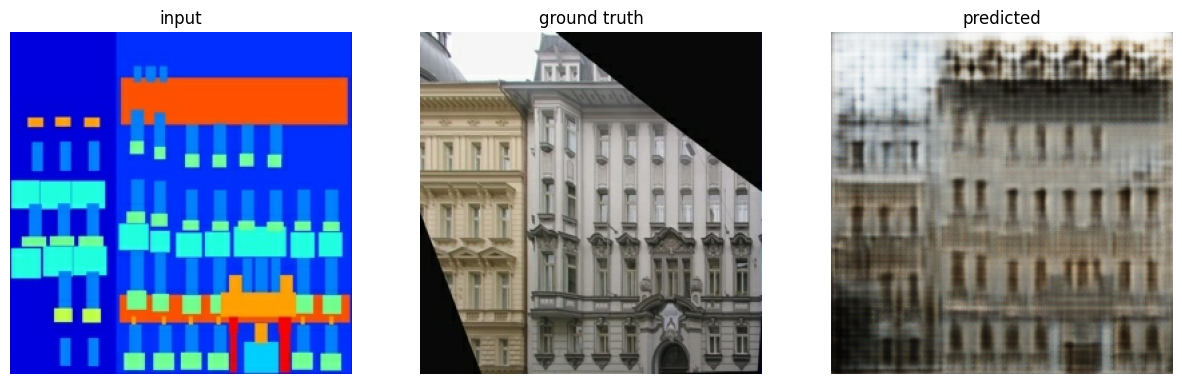

step 3k
....................................................................................................

In [33]:
def fit(train_ds, test_ds, steps):
    example_input, example_target = next(iter(test_ds.take(1)))
    start = time.time()
    for step, (inp, tar) in train_ds.repeat().take(steps).enumerate():
        if step % 1000 == 0:
            display.clear_output(wait=True)
            if step != 0: print(f'{time.time()-start:.1f}s for last 1000 steps')
            start = time.time()
            generate_images(generator, example_input, example_target)
            print(f'step {step//1000}k')
        train_step(inp, tar, step)
        if step % 10 == 0: print('.', end='', flush=True)
        if (step+1) % 5000 == 0: checkpoint.save(file_prefix=checkpoint_dir+'/ckpt')

STEPS = 4000 # drop to ~4000 for a quick test run
fit(train_dataset, test_dataset, STEPS)

In [34]:
# in case colab disconnects mid training, restore and continue
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

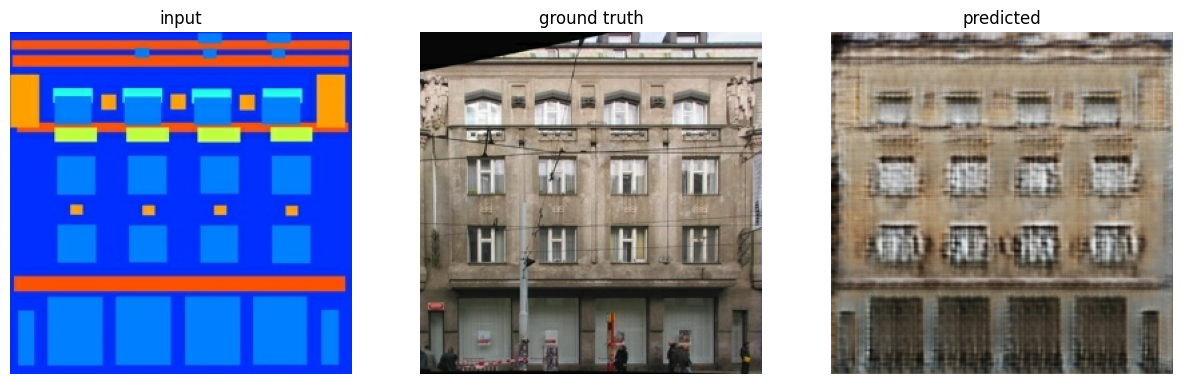

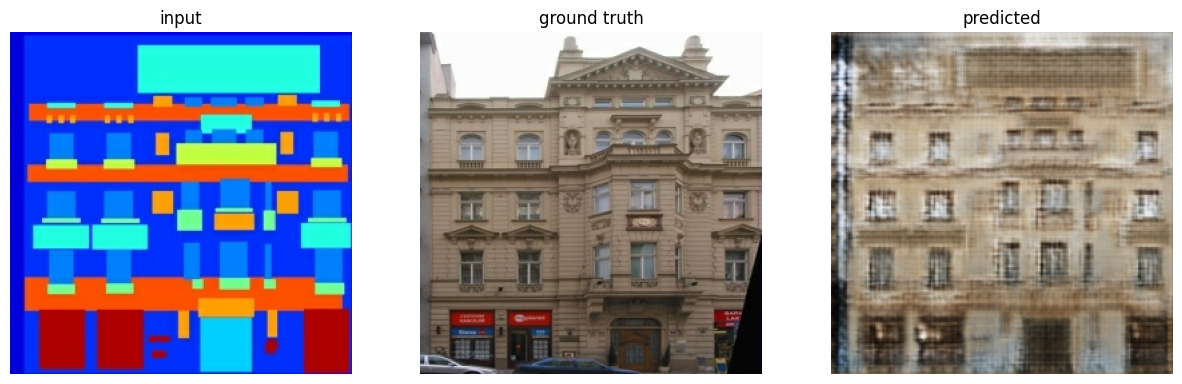

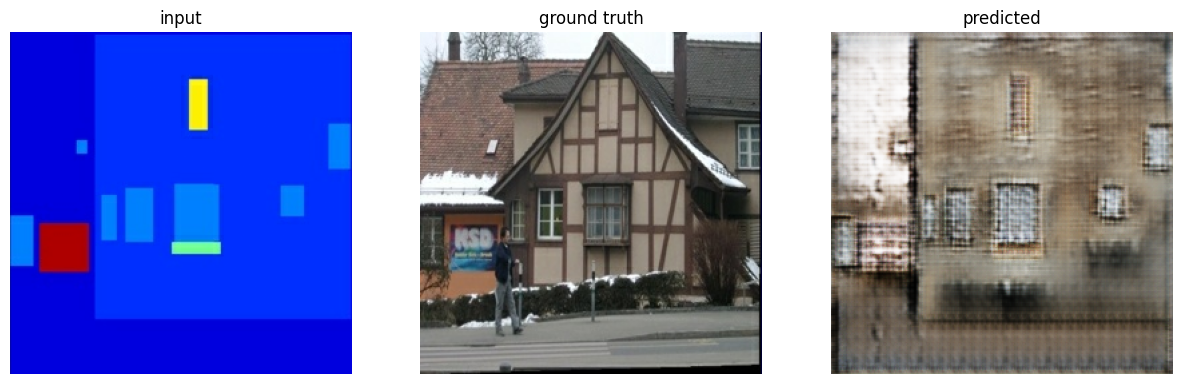

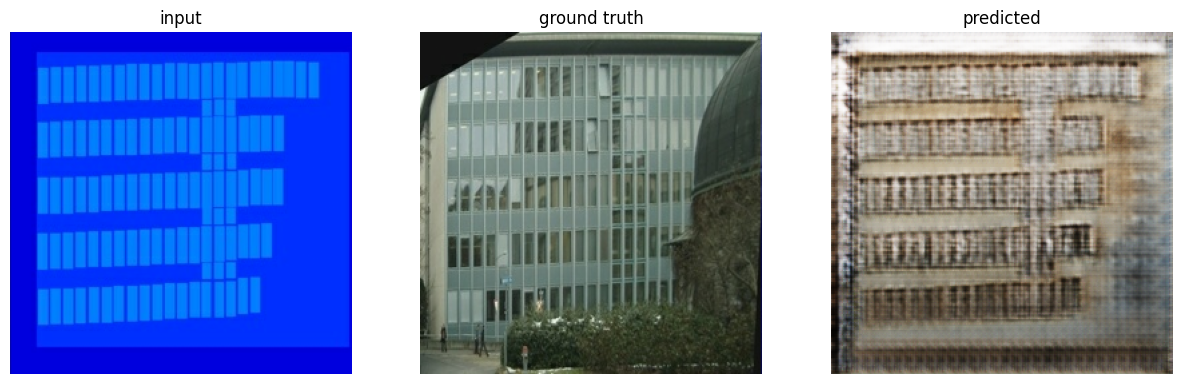

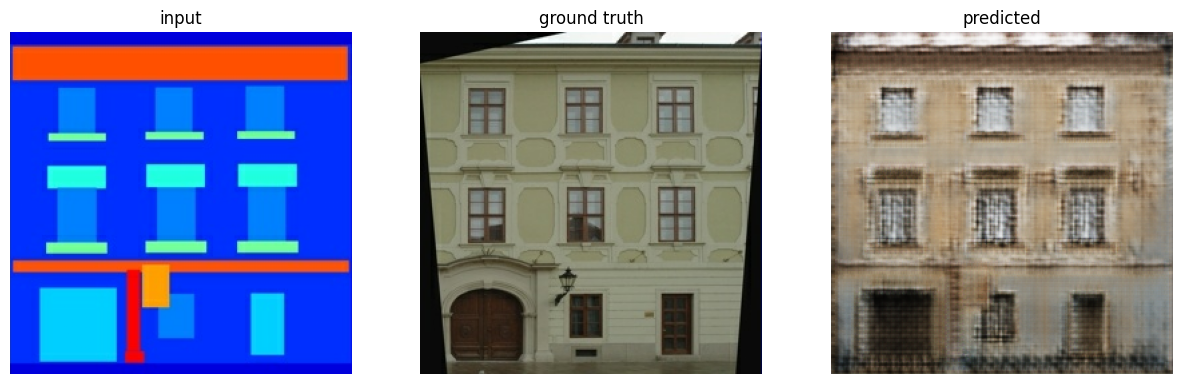

In [35]:
for inp, tar in test_dataset.take(5):
    generate_images(generator, inp, tar)

In [36]:
generator.save('pix2pix_facades_generator.keras')